<a href="https://colab.research.google.com/github/Takayoshi-code/nanoGPT-class/blob/master/nanoGPT_Aozora_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title STEP1 nanoGPT環境をGitHubからダウンロードしてGoogle Corab上に展開します。このSTEP1は一度だけ実行し、以降は、本スクリプトの後ろにあるGoogle Driveへの保存スクリプトでセーブしたり復帰スクリプトを使ってください。
# ===== 安全版 =====

import os

print("===== Step 0: /content に移動 =====")
%cd /content

print("===== Step 1: クリーン =====")
!rm -rf nanoGPT
!rm -f master.zip

print("===== Step 2: ライブラリ =====")
!pip install -q sentencepiece datasets tqdm

print("===== Step 3: nanoGPT取得 =====")

!wget -q https://github.com/Takayoshi-code/nanoGPT-class/archive/refs/heads/master.zip
!unzip -q master.zip
!mv nanoGPT-class-master nanoGPT

print("===== Step 4: 移動 =====")
%cd /content/nanoGPT

print("===== Step 5: 確認 =====")
!ls

===== Step 0: /content に移動 =====
/content
===== Step 1: クリーン =====
===== Step 2: ライブラリ =====
===== Step 3: nanoGPT取得 =====
===== Step 4: 移動 =====
/content/nanoGPT
===== Step 5: 確認 =====
assets		 LICENSE		    scaling_laws.ipynb
bench.py	 model.py		    train.py
config		 nanoGPT_Aozora_tiny.ipynb  transformer_sizing.ipynb
configurator.py  README.md
data		 sample.py


In [ ]:
# @title 青空文庫収録作家一覧
import io
import zipfile
import requests
import pandas as pd

URL = "https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip"

print("青空文庫のデータを取得中...")

r = requests.get(URL, timeout=60)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_name = [x for x in z.namelist() if x.endswith(".csv")][0]
    with z.open(csv_name) as f:
        df = pd.read_csv(f, low_memory=False)

df["作家名"] = (
    df["姓"].fillna("").astype(str).str.strip()
    + " "
    + df["名"].fillna("").astype(str).str.strip()
).str.strip()

authors = (
    df.groupby(["人物ID", "作家名"], as_index=False)
      .agg(公開作品数=("作品ID", "nunique"))
      .sort_values(["作家名", "人物ID"])
      .reset_index(drop=True)
)

print(f"\n収録作家数: {len(authors):,}人")
print("=" * 70)

for i, row in authors.iterrows():
    print(
        f"{i:4d}: {row['作家名']:<20} "
        f"人物ID={row['人物ID']:<6} "
        f"作品数={row['公開作品数']}"
    )

青空文庫のデータを取得中...

収録作家数: 1,335人
   0: Morishous T.H.E creative 人物ID=2255   作品数=2
   1: The Creative CAT     人物ID=1834   作品数=31
   2: hiro                 人物ID=1280   作品数=2
   3: sogo                 人物ID=913    作品数=3
   4: かぐつち みどり             人物ID=968    作品数=1
   5: ささき ふさ               人物ID=911    作品数=1
   6: とだ けん                人物ID=970    作品数=1
   7: アイプ・ロシディ             人物ID=2313   作品数=1
   8: アインシュタイン アルベルト       人物ID=1428   作品数=1
   9: アウンチェイン              人物ID=2396   作品数=1
  10: アポリネール ギヨーム          人物ID=2135   作品数=1
  11: アミーチス エドモンド・デ        人物ID=1048   作品数=1
  12: アラルコン ペドロ・アントニオ      人物ID=1716   作品数=1
  13: アリ サバハッティン           人物ID=2315   作品数=1
  14: アルチバシェッフ ミハイル・ペトローヴィチ 人物ID=366    作品数=3
  15: アルテンベルク ペーター         人物ID=1190   作品数=1
  16: アレニウス スヴァンテ          人物ID=226    作品数=1
  17: アレン ジェームズ            人物ID=1842   作品数=1
  18: アレン リリー・Ｌ            人物ID=1843   作品数=1
  19: アンデルセン ハンス・クリスチャン    人物ID=19     作品数=51
  20: アンドレーエフ レオニード・ニコラーエヴィチ 人物ID=907    作品数=2
  21: アークム フレデリ

In [ ]:
# @title STEP2 作家、作品を選んでクリーニングして入力コーパスを作成します。
import io
import os
import re
import zipfile
import requests
import pandas as pd
from tqdm import tqdm
from bs4 import BeautifulSoup
from urllib.parse import urljoin

CSV_ZIP_URL = "https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip"
BASE_DIR = "/content/nanoGPT/novel_selected"
RAW_OUTPUT = os.path.join(BASE_DIR, "selected_works.txt")
CLEAN_OUTPUT = os.path.join(BASE_DIR, "selected_works_clean.txt")
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; AozoraDownloader/1.0)"}

def normalize_name(s):
    if pd.isna(s):
        return ""
    return str(s).replace(" ", "").replace("　", "").strip()

def decode_aozora_text(raw):
    for enc in ["shift_jis", "cp932", "utf-8-sig", "utf-8"]:
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            pass
    raise RuntimeError("文字コードを判定できませんでした。")

def clean_text(text):
    lines = text.split("\n")
    result = []
    started = False

    for line in lines:
        raw = line
        line = line.strip()

        if line.startswith("<|title|>"):
            continue
        if line.startswith("<|author|>"):
            continue

        if not started:
            if raw.startswith("　") and len(line) > 10 and "。" in line:
                started = True
            else:
                continue

        if (
            line.startswith("底本")
            or line.startswith("初出")
            or line.startswith("入力")
            or line.startswith("校正")
            or line.startswith("青空文庫")
            or line.startswith("作成ファイル")
            or "青空文庫作成ファイル" in line
        ):
            break

        if (
            "記号について" in line
            or "JIS" in line
            or "入力に使用" in line
            or "校正に使用" in line
        ):
            continue

        if re.fullmatch(r"[一二三四五六七八九十百千万]+", line):
            continue

        if re.fullmatch(r"[ⅠⅡⅢⅣⅤⅥⅦⅧⅨⅩ]+", line):
            continue

        if line in {"上", "中", "下", "前編", "後編", "序", "跋", "附録", "解説"}:
            continue

        line = re.sub(r"｜", "", line)
        line = re.sub(r"《.*?》", "", line)
        line = re.sub(r"［＃.*?］", "", line)
        line = re.sub(r"〔.*?〕", "", line)
        line = re.sub(r"（注.*?）", "", line)
        line = re.sub(r"（[\d０-９]+）", "", line)

        line = line.replace("／＼", "")
        line = line.replace("※", "")
        line = line.replace("＊", "")

        if re.fullmatch(r"[0-9０-９A-Za-z]+", line):
            continue

        if len(line) < 2:
            continue

        result.append(line)

    text = "\n".join(result)
    text = re.sub(r"\n{3,}", "\n\n", text)

    if text.count("。") < 10:
        return ""

    if len(text) < 1000:
        return ""

    return text.strip()

def download_work(card_url):
    r = requests.get(card_url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    r.encoding = r.apparent_encoding
    soup = BeautifulSoup(r.text, "html.parser")

    zip_candidates = []

    for a in soup.find_all("a", href=True):
        href = a["href"]
        if href.lower().split("?")[0].endswith(".zip"):
            url = urljoin(card_url, href)
            label = a.get_text(" ", strip=True)
            priority = 0 if "テキスト" in label else 1
            zip_candidates.append((priority, url))

    if not zip_candidates:
        return None

    zip_candidates.sort(key=lambda x: x[0])

    for _, zip_url in zip_candidates:
        try:
            r = requests.get(zip_url, headers=HEADERS, timeout=60)
            r.raise_for_status()

            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                txt_files = [name for name in z.namelist() if name.lower().endswith(".txt")]

                if not txt_files:
                    continue

                raw = z.read(txt_files[0])
                return decode_aozora_text(raw)

        except Exception:
            continue

    return None

def main():
    os.makedirs(BASE_DIR, exist_ok=True)

    print("青空文庫の作品一覧を取得しています...")

    r = requests.get(CSV_ZIP_URL, headers=HEADERS, timeout=60)
    r.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(".csv")]
        if not csv_files:
            raise RuntimeError("CSVが見つかりません。")
        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f, low_memory=False)

    print(f"登録データ数: {len(df):,}")

    df["作家名"] = (
        df["姓"].fillna("").astype(str).str.strip()
        + " "
        + df["名"].fillna("").astype(str).str.strip()
    ).str.strip()

    df["作家名検索用"] = df["作家名"].apply(normalize_name)

    keyword = input("作家名を入力してください: ").strip()
    keyword_normalized = normalize_name(keyword)

    mask = df["作家名検索用"].str.contains(
        keyword_normalized,
        na=False,
        regex=False
    )

    authors = (
        df.loc[mask, ["人物ID", "作家名"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if len(authors) == 0:
        raise ValueError(f"「{keyword}」に該当する作家が見つかりません。")

    print("\n=== 作家候補 ===")

    for i, row in authors.iterrows():
        print(f"{i:3d}: {row['作家名']} (人物ID={row['人物ID']})")

    if len(authors) == 1:
        n = 0
        print("候補が1人なので自動選択します。")
    else:
        while True:
            try:
                n = int(input("左端の選択番号を入力してください: "))
                if 0 <= n < len(authors):
                    break
            except ValueError:
                pass
            print(f"0～{len(authors)-1}を入力してください。")

    author_id = authors.iloc[n]["人物ID"]
    author_name = authors.iloc[n]["作家名"]

    print(f"\n選択した作家: {author_name} (人物ID={author_id})")

    columns = ["作品ID", "作品名", "図書カードURL"]

    if "副題" in df.columns:
        columns.insert(2, "副題")

    works = (
        df.loc[df["人物ID"] == author_id, columns]
        .drop_duplicates(subset=["作品ID"])
        .reset_index(drop=True)
    )

    print(f"\n=== {author_name} の作品一覧（{len(works)}作品）===")

    for i, row in works.iterrows():
        title = str(row["作品名"])

        if "副題" in works.columns and pd.notna(row["副題"]):
            subtitle = str(row["副題"]).strip()
            if subtitle:
                title += " ― " + subtitle

        print(f"{i:3d}: {title} (作品ID={row['作品ID']})")

    print("\n複数選択できます。")
    print("例: 0,3,5,8")
    print("全作品: all")

    selection = input("作品番号を入力してください: ").strip()

    if selection.lower() == "all":
        selected_indices = list(range(len(works)))
    else:
        try:
            selected_indices = [int(x.strip()) for x in selection.split(",")]
        except ValueError:
            raise ValueError("作品番号は 0,3,5 の形式で入力してください。")

    selected_indices = list(dict.fromkeys(selected_indices))

    for i in selected_indices:
        if i < 0 or i >= len(works):
            raise ValueError(f"作品番号 {i} は範囲外です。")

    print(f"\n{len(selected_indices)}作品をダウンロードします。")

    downloaded = []

    for number, i in enumerate(selected_indices, 1):
        work = works.iloc[i]
        title = str(work["作品名"])
        card_url = str(work["図書カードURL"])

        print(f"[{number}/{len(selected_indices)}] {title}")

        try:
            text = download_work(card_url)
        except Exception as e:
            print(f"  → ERROR: {e}")
            continue

        if text is None:
            print("  → TXTを取得できませんでした。")
            continue

        downloaded.append({
            "title": title,
            "text": text
        })

        print(f"  → OK {len(text):,} chars")

    if not downloaded:
        raise RuntimeError("作品を1件も取得できませんでした。")

    print(f"\nRAWファイルを作成: {RAW_OUTPUT}")

    with open(RAW_OUTPUT, "w", encoding="utf-8") as out:
        for item in downloaded:
            out.write(f"<|title|>{item['title']}\n")
            out.write(f"<|author|>{author_name}\n")
            out.write(item["text"])
            out.write("\n\n<|endoftext|>\n\n")

    original_size = os.path.getsize(RAW_OUTPUT)

    print("\nクリーニングを開始します...")

    total = len(downloaded)
    kept = 0
    total_chars = 0

    with open(CLEAN_OUTPUT, "w", encoding="utf-8") as out:
        for item in tqdm(downloaded):
            cleaned = clean_text(item["text"])

            if cleaned:
                chars = len(cleaned)
                kept += 1
                total_chars += chars

                print(f"Work {kept:2d}: {item['title']} : {chars:,} chars")

                out.write(cleaned)
                out.write("\n\n<|endoftext|>\n\n")
            else:
                print(f"REMOVED: {item['title']}")

    cleaned_size = os.path.getsize(CLEAN_OUTPUT)

    print()
    print("====================================")
    print(f"Author           : {author_name}")
    print(f"Selected works   : {len(selected_indices)}")
    print(f"Downloaded works : {total}")
    print(f"Kept works       : {kept}")
    print(f"Removed works    : {total-kept}")
    print("------------------------------------")
    print(f"Total chars      : {total_chars:,}")
    print(f"Original size    : {original_size/1024:.1f} KB")
    print(f"Cleaned size     : {cleaned_size/1024:.1f} KB")

    if original_size > 0:
        print(f"Reduction        : {100*(1-cleaned_size/original_size):.1f}%")

    print("------------------------------------")
    print(f"RAW output       : {RAW_OUTPUT}")
    print(f"Clean output     : {CLEAN_OUTPUT}")
    print("====================================")

if __name__ == "__main__":
    main()

青空文庫の作品一覧を取得しています...
登録データ数: 19,502
作家名を入力してください: 太宰治

=== 作家候補 ===
  0: 太宰 治 (人物ID=35)
候補が1人なので自動選択します。

選択した作家: 太宰 治 (人物ID=35)

=== 太宰 治 の作品一覧（274作品）===
  0: ア、秋 (作品ID=236)
  1: I can speak (作品ID=1572)
  2: 愛と美について (作品ID=1578)
  3: 青森 (作品ID=46597)
  4: 青森 (作品ID=4357)
  5: 朝 (作品ID=1562)
  6: あさましきもの (作品ID=240)
  7: 新しい形の個人主義 (作品ID=42360)
  8: 兄たち (作品ID=239)
  9: 雨の玉川心中 ― 02 遺書 (作品ID=58054)
 10: 或る忠告 (作品ID=42356)
 11: 老ハイデルベルヒ (作品ID=238)
 12: 『老ハイデルベルヒ』序 (作品ID=54179)
 13: 一日の労苦 (作品ID=1592)
 14: 一問一答 (作品ID=1598)
 15: 一灯 (作品ID=273)
 16: 一歩前進二歩退却 (作品ID=1593)
 17: 田舎者 (作品ID=42362)
 18: 『井伏鱒二選集』後記 (作品ID=42359)
 19: 陰火 (作品ID=272)
 20: ヴィヨンの妻 (作品ID=2253)
 21: 嘘 (作品ID=2254)
 22: 右大臣実朝 (作品ID=2255)
 23: 鬱屈禍 (作品ID=42354)
 24: 姥捨 (作品ID=2256)
 25: 『姥捨』あとがき (作品ID=54169)
 26: 海 (作品ID=42363)
 27: 炎天汗談 (作品ID=43071)
 28: 黄金風景 (作品ID=2257)
 29: 黄村先生言行録 (作品ID=287)
 30: 桜桃 (作品ID=308)
 31: 緒方氏を殺した者 (作品ID=42364)
 32: おさん (作品ID=305)
 33: おしゃれ童子 (作品ID=306)
 34: 織田君の死 (作品ID=42365)
 35: お伽草紙 (作品ID=52380)
 36: お伽草

100%|██████████| 1/1 [00:00<00:00, 359.01it/s]

Work  1: 走れメロス : 9,888 chars

Author           : 太宰 治
Selected works   : 1
Downloaded works : 1
Kept works       : 1
Removed works    : 0
------------------------------------
Total chars      : 9,888
Original size    : 31.5 KB
Cleaned size     : 28.8 KB
Reduction        : 8.3%
------------------------------------
RAW output       : /content/nanoGPT/novel_selected/selected_works.txt
Clean output     : /content/nanoGPT/novel_selected/selected_works_clean.txt


In [ ]:
# @title OPTIONAL 英語文学の作家、作品検索とダウンロード
# ============================================================
# Standard Ebooks 授業用作品ダウンロード
# 日本での利用を考慮して古い英語原著の作家に限定
# GitHub APIの全repository走査は行わない
# ============================================================

import os
import re
import requests
import subprocess
import shutil
from bs4 import BeautifulSoup

BASE = "/content/nanoGPT"
OUT_DIR = os.path.join(BASE, "novel_selected")
WORK_DIR = os.path.join(OUT_DIR, "repos")
RAW_OUTPUT = os.path.join(OUT_DIR, "selected_works.txt")
CLEAN_OUTPUT = os.path.join(OUT_DIR, "selected_works_clean.txt")

os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# 授業用作家リスト
# 原則として古い英語原著の作家に限定
# ============================================================

SAFE_AUTHORS = [
    ("William Shakespeare", "william-shakespeare", 1616),
    ("Daniel Defoe", "daniel-defoe", 1731),
    ("Jonathan Swift", "jonathan-swift", 1745),
    ("Samuel Johnson", "samuel-johnson", 1784),
    ("Robert Burns", "robert-burns", 1796),
    ("Jane Austen", "jane-austen", 1817),
    ("William Blake", "william-blake", 1827),
    ("Walter Scott", "walter-scott", 1832),
    ("Edgar Allan Poe", "edgar-allan-poe", 1849),
    ("Emily Brontë", "emily-bronte", 1848),
    ("Mary Shelley", "mary-shelley", 1851),
    ("Charlotte Brontë", "charlotte-bronte", 1855),
    ("Henry David Thoreau", "henry-david-thoreau", 1862),
    ("Elizabeth Gaskell", "elizabeth-gaskell", 1865),
    ("Charles Dickens", "charles-dickens", 1870),
    ("George Eliot", "george-eliot", 1880),
    ("Herman Melville", "herman-melville", 1891),
    ("Walt Whitman", "walt-whitman", 1892),
    ("Robert Louis Stevenson", "robert-louis-stevenson", 1894),
    ("Lewis Carroll", "lewis-carroll", 1898),
    ("Oscar Wilde", "oscar-wilde", 1900),
    ("Mark Twain", "mark-twain", 1910),
    ("O. Henry", "o-henry", 1910),
    ("Bram Stoker", "bram-stoker", 1912),
    ("Henry James", "henry-james", 1916),
    ("Jack London", "jack-london", 1916),
    ("Joseph Conrad", "joseph-conrad", 1924),
    ("Thomas Hardy", "thomas-hardy", 1928),
    ("Arthur Conan Doyle", "arthur-conan-doyle", 1930),
    ("D. H. Lawrence", "d-h-lawrence", 1930),
    ("Rudyard Kipling", "rudyard-kipling", 1936),
    ("H. P. Lovecraft", "h-p-lovecraft", 1937),
    ("Edith Wharton", "edith-wharton", 1937),
    ("F. Scott Fitzgerald", "f-scott-fitzgerald", 1940),
    ("James Joyce", "james-joyce", 1941),
    ("Virginia Woolf", "virginia-woolf", 1941),
]

# ============================================================
# 作家一覧
# ============================================================

print("=" * 70)
print("Standard Ebooks 授業用作家一覧")
print("=" * 70)

for i, (name, slug, death) in enumerate(SAFE_AUTHORS, 1):
    print(f"{i:3d}: {name:<28} 没年 {death}")

print("=" * 70)
print("作家数:", len(SAFE_AUTHORS))
print()

# ============================================================
# 作家選択
# ============================================================

while True:
    try:
        author_no = int(input("作家番号を入力してください: "))
        if 1 <= author_no <= len(SAFE_AUTHORS):
            break
    except ValueError:
        pass
    print("正しい番号を入力してください。")

author_name, author_slug, death_year = SAFE_AUTHORS[author_no - 1]

print()
print("=" * 70)
print("選択した作家:", author_name)
print("没年        :", death_year)
print("=" * 70)

# ============================================================
# GitHub Search API
# 選択した作家だけを検索
# ============================================================

print()
print("Standard Ebooksから作品を検索しています...")

query = f"org:standardebooks {author_slug} in:name"

url = "https://api.github.com/search/repositories"

params = {
    "q": query,
    "per_page": 100
}

headers = {
    "Accept": "application/vnd.github+json",
    "User-Agent": "nanoGPT-Colab"
}

r = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=30
)

if r.status_code == 403:
    raise RuntimeError(
        "GitHub APIのアクセス上限に達しています。\n"
        "しばらく待ってから再実行してください。"
    )

r.raise_for_status()

data = r.json()

items = data.get("items", [])

# ============================================================
# 選択作家のrepositoryだけ残す
# ============================================================

prefix = author_slug + "_"

repos = []

for repo in items:
    name = repo["name"]

    if not name.startswith(prefix):
        continue

    # 翻訳者等が付加されたrepositoryを安全側で除外
    # 基本形式:
    # author_title
    #
    # 翻訳作品では:
    # author_title_translator
    #
    # のようになることがある

    after_author = name[len(prefix):]

    # descriptionからタイトルを取得
    description = repo.get("description") or ""

    m = re.search(
        r"Epub source for the Standard Ebooks edition of (.+?), by ",
        description
    )

    if m:
        title = m.group(1).strip()
    else:
        title = after_author.replace("-", " ").title()

    repos.append({
        "name": name,
        "title": title,
        "url": repo["clone_url"],
        "description": description
    })

# ============================================================
# 重複削除
# ============================================================

unique = {}

for repo in repos:
    unique[repo["name"]] = repo

repos = list(unique.values())

repos.sort(
    key=lambda x: x["title"].lower()
)

if not repos:
    raise RuntimeError(
        f"{author_name} の作品が見つかりませんでした。"
    )

# ============================================================
# 作品一覧
# ============================================================

print()
print("=" * 70)
print(author_name)
print("=" * 70)

for i, repo in enumerate(repos, 1):
    print(f"{i:3d}: {repo['title']}")

print("=" * 70)
print("作品数:", len(repos))
print()

# ============================================================
# 作品選択
# ============================================================

print("作品番号を入力してください。")
print("複数選択例: 1,3,5")
print("全作品    : all")

selection = input("作品番号: ").strip()

if selection.lower() == "all":
    selected = repos
else:
    indices = []
    for x in selection.split(","):
        try:
            n = int(x.strip())
            if 1 <= n <= len(repos):
                indices.append(n - 1)
        except ValueError:
            pass

    selected = [repos[i] for i in indices]

if not selected:
    raise RuntimeError("作品が選択されていません。")

# ============================================================
# 作業フォルダ初期化
# ============================================================

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

os.makedirs(WORK_DIR, exist_ok=True)

raw_texts = []
clean_texts = []

# ============================================================
# ダウンロード
# ============================================================

for no, work in enumerate(selected, 1):

    print()
    print(
        f"[{no}/{len(selected)}] "
        f"{work['title']}"
    )

    repo_dir = os.path.join(
        WORK_DIR,
        work["name"]
    )

    result = subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            work["url"],
            repo_dir
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print("ERROR:", result.stderr)
        continue

    # ========================================================
    # Standard Ebooks本文
    # ========================================================

    text_dir = os.path.join(
        repo_dir,
        "src",
        "epub",
        "text"
    )

    if not os.path.isdir(text_dir):
        print("本文フォルダがありません。")
        continue

    xhtml_files = sorted(
        f for f in os.listdir(text_dir)
        if f.endswith(".xhtml")
    )

    # ========================================================
    # 本文ではないファイル
    # ========================================================

    skip_files = {
        "colophon.xhtml",
        "imprint.xhtml",
        "titlepage.xhtml",
        "halftitlepage.xhtml",
        "toc.xhtml",
        "uncopyright.xhtml",
        "dedication.xhtml"
    }

    work_raw = []
    work_clean = []

    # ========================================================
    # XHTMLから本文抽出
    # ========================================================

    for filename in xhtml_files:

        if filename in skip_files:
            continue

        path = os.path.join(
            text_dir,
            filename
        )

        with open(
            path,
            "r",
            encoding="utf-8"
        ) as f:
            html = f.read()

        work_raw.append(html)

        soup = BeautifulSoup(
            html,
            "html.parser"
        )

        # script/style削除
        for tag in soup(
            ["script", "style"]
        ):
            tag.decompose()

        # ====================================================
        # 本文取得
        # ====================================================

        text = soup.get_text(
            separator="\n",
            strip=True
        )

        # ====================================================
        # クリーニング
        # ====================================================

        # 改行コード統一
        text = text.replace(
            "\r\n",
            "\n"
        ).replace(
            "\r",
            "\n"
        )

        # 行内の連続空白
        text = re.sub(
            r"[ \t]+",
            " ",
            text
        )

        # 行頭・行末空白
        text = "\n".join(
            line.strip()
            for line in text.splitlines()
        )

        # 3個以上の改行
        text = re.sub(
            r"\n{3,}",
            "\n\n",
            text
        )

        text = text.strip()

        if text:
            work_clean.append(text)

    # ========================================================
    # 作品単位で結合
    # ========================================================

    raw = "\n\n".join(work_raw)

    clean = "\n\n".join(work_clean)

    raw_texts.append(raw)

    clean_texts.append(clean)

    print(
        "OK:",
        f"{len(clean):,}",
        "characters"
    )

# ============================================================
# 全作品結合
# ============================================================

raw_final = "\n\n".join(raw_texts)

clean_final = "\n\n".join(clean_texts)

# ============================================================
# 保存
# ============================================================

with open(
    RAW_OUTPUT,
    "w",
    encoding="utf-8"
) as f:
    f.write(raw_final)

with open(
    CLEAN_OUTPUT,
    "w",
    encoding="utf-8"
) as f:
    f.write(clean_final)

# ============================================================
# 結果
# ============================================================

print()
print("=" * 70)
print("Author       :", author_name)
print("Death year   :", death_year)
print("Selected     :", len(selected))
print("Characters   :", f"{len(clean_final):,}")
print()
print("RAW output   :", RAW_OUTPUT)
print("Clean output :", CLEAN_OUTPUT)
print("=" * 70)

print()
print("注意:")
print("この作家一覧は授業用に安全側へ限定した候補です。")
print("日本での著作権消滅を法的に保証するものではありません。")
print("翻訳・編集・挿絵等には別個の権利が存在する場合があります。")

In [ ]:
# @title STEP3 　SentencePieceのトークナイザを動かしダウンロードした作品に登場するトークンを学習する。
# ============================================================
# STEP3
# 入力コーパスからSentencePiece Tokenizerを学習
# Unigram版
# ============================================================

import os
import time
import sentencepiece as spm

BASE = "/content/nanoGPT"
INPUT = "/content/nanoGPT/novel_selected/selected_works_clean.txt"
MODEL_PREFIX = os.path.join(BASE, "jp")

# =========================
# 入力ファイル確認
# =========================
if not os.path.exists(INPUT):
    raise FileNotFoundError(INPUT)

with open(INPUT, "r", encoding="utf-8") as f:
    text = f.read()

print("=== STEP3 SentencePiece Training ===")
print("Input       :", INPUT)
print("Characters  :", f"{len(text):,}")
print("Lines       :", f"{len(text.splitlines()):,}")

# =========================
# 古いTokenizerを削除
# =========================
for ext in [".model", ".vocab"]:
    path = MODEL_PREFIX + ext
    if os.path.exists(path):
        os.remove(path)

# =========================
# SentencePiece学習（Unigram）
# =========================
start = time.time()

spm.SentencePieceTrainer.train(
    input=INPUT,
    model_prefix=MODEL_PREFIX,
    vocab_size=8000,
    character_coverage=0.9995,
    model_type="unigram",
    num_threads=8,
    input_sentence_size=2000000,
    shuffle_input_sentence=True,
    max_sentence_length=4096,
    byte_fallback=True,
    hard_vocab_limit=False,
    user_defined_symbols=["<|endoftext|>"]
)

elapsed = time.time() - start

# =========================
# Tokenizer読み込み
# =========================
sp = spm.SentencePieceProcessor()
sp.load(MODEL_PREFIX + ".model")

# =========================
# 全文を試しにTokenize
# ※ binファイルはまだ作らない
# =========================
ids = sp.encode(text, out_type=int)

unk_id = sp.unk_id()
unk_count = sum(i == unk_id for i in ids)
unk_rate = unk_count / len(ids) * 100 if ids else 0
avg_chars = len(text) / len(ids) if ids else 0

# =========================
# 基本情報
# =========================
print()
print("=== STEP3 DONE ===")
print("Tokenizer    :", MODEL_PREFIX + ".model")
print("Vocabulary   :", MODEL_PREFIX + ".vocab")
print("Model type   : Unigram")
print("vocab_size   :", f"{sp.get_piece_size():,}")
print("unk_id       :", sp.unk_id())
print("eot_id       :", sp.piece_to_id("<|endoftext|>"))
print("Training time:", f"{elapsed:.2f} sec")

# =========================
# Tokenizer統計
# =========================
print()
print("=== Tokenizer Statistics ===")
print("Characters   :", f"{len(text):,}")
print("Tokens       :", f"{len(ids):,}")
print("Chars/token  :", f"{avg_chars:.2f}")
print("UNK tokens   :", f"{unk_count:,}")
print("UNK rate     :", f"{unk_rate:.4f}%")

# =========================
# Tokenize例
# =========================
sample = text[:100]
sample_ids = sp.encode(sample, out_type=int)

print()
print("=== Tokenization Example ===")
print("Text:")
print(sample)

print()
print("Tokens:")
print(" | ".join(sp.id_to_piece(i) for i in sample_ids))

print()
print("Token IDs:")
print(sample_ids)

# =========================
# 長いtokenの例
# =========================
pieces = [
    sp.id_to_piece(i)
    for i in range(sp.get_piece_size())
]

# special tokenとbyte fallbackを除外
normal_pieces = [
    p for p in pieces
    if not p.startswith("<")
]

long_pieces = sorted(
    normal_pieces,
    key=lambda p: len(p.replace("▁", "")),
    reverse=True
)

print()
print("=== Long Token Examples ===")

for p in long_pieces[:10]:
    visible = p.replace("▁", "")
    print(
        f"{len(visible):2d} chars : {repr(p)}"
    )

=== STEP3 SentencePiece Training ===
Input       : /content/nanoGPT/novel_selected/selected_works_clean.txt
Characters  : 9,905
Lines       : 78

=== STEP3 DONE ===
Tokenizer    : /content/nanoGPT/jp.model
Vocabulary   : /content/nanoGPT/jp.vocab
Model type   : Unigram
vocab_size   : 1,876
unk_id       : 0
eot_id       : 3
Training time: 0.05 sec

=== Tokenizer Statistics ===
Characters   : 9,905
Tokens       : 5,979
Chars/token  : 1.66
UNK tokens   : 0
UNK rate     : 0.0000%

=== Tokenization Example ===
Text:
メロスは激怒した。必ず、かの邪智暴虐の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった

Tokens:
▁メロスは | 激 | 怒 | した | 。 | 必 | ず | 、 | か | の | 邪智 | 暴 | 虐 | の王 | を | 除 | かなければならぬ | と | 決 | 意 | した | 。 | メロスには | 政 | 治 | が | わからぬ | 。 | メロスは | 、 | 村の | 牧人 | で | ある | 。 | 笛 | を | 吹 | き | 、 | 羊 | と | 遊 | んで | 暮し | て来た | 。 | けれども | 邪 | 悪 | に | 対 | しては | 、 | 人 | 一 | 倍 | に | 敏 | 感 | であった

Token IDs:
[344, 410, 771, 277, 261, 480, 311, 260, 283, 264, 646, 1263, 736, 1609, 263, 1

In [ ]:
# @title STEP4　入力コーパスを学習用データと検証用データの２つに分けます。
# ============================================================
# STEP4
# 入力コーパスをTokenizeして
# train / validationデータに分割
# ============================================================

import os
import pickle
import numpy as np
import sentencepiece as spm

BASE = "/content/nanoGPT"
INPUT = "/content/nanoGPT/novel_selected/selected_works_clean.txt"
MODEL = os.path.join(BASE, "jp.model")
OUT_DIR = os.path.join(BASE, "data", "jp")

# =========================
# ファイル確認
# =========================
if not os.path.exists(INPUT):
    raise FileNotFoundError(INPUT)

if not os.path.exists(MODEL):
    raise FileNotFoundError(MODEL)

os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# Tokenizer読み込み
# =========================
sp = spm.SentencePieceProcessor()
sp.load(MODEL)

print("=== STEP4 Encoding ===")
print("Tokenizer  :", MODEL)
print("vocab_size :", sp.get_piece_size())

# =========================
# コーパス全文読み込み
# =========================
with open(INPUT, "r", encoding="utf-8") as f:
    text = f.read()

print("Characters :", f"{len(text):,}")
print("Lines      :", f"{len(text.splitlines()):,}")

# =========================
# 全文をそのままTokenize
# =========================
ids = sp.encode(text, out_type=int)

print("Total tokens:", f"{len(ids):,}")

# =========================
# UNK確認
# =========================
unk_id = sp.unk_id()
unk_count = sum(token_id == unk_id for token_id in ids)

if len(ids) > 0:
    unk_rate = unk_count / len(ids) * 100
else:
    unk_rate = 0.0

print("UNK tokens :", unk_count)
print("UNK rate   :", f"{unk_rate:.4f}%")

if len(ids) == 0:
    raise RuntimeError("Tokenが0個です。")

# =========================
# train 90% / validation 10%
# =========================
n = int(len(ids) * 0.9)

train_ids = np.array(
    ids[:n],
    dtype=np.uint16
)

val_ids = np.array(
    ids[n:],
    dtype=np.uint16
)

print()
print("=== Split ===")
print("train tokens:", f"{len(train_ids):,}")
print("val tokens  :", f"{len(val_ids):,}")

# =========================
# 保存
# =========================
train_path = os.path.join(OUT_DIR, "train.bin")
val_path = os.path.join(OUT_DIR, "val.bin")
meta_path = os.path.join(OUT_DIR, "meta.pkl")

train_ids.tofile(train_path)
val_ids.tofile(val_path)

meta = {
    "vocab_size": sp.get_piece_size()
}

with open(meta_path, "wb") as f:
    pickle.dump(meta, f)

# =========================
# 保存結果を再読込して確認
# =========================
train_check = np.memmap(
    train_path,
    dtype=np.uint16,
    mode="r"
)

val_check = np.memmap(
    val_path,
    dtype=np.uint16,
    mode="r"
)

print()
print("=== FILE VERIFY ===")
print("train.bin :", len(train_check), "tokens")
print("val.bin   :", len(val_check), "tokens")
print("meta.pkl  : vocab_size =", meta["vocab_size"])

assert len(train_check) == len(train_ids)
assert len(val_check) == len(val_ids)

# =========================
# nanoGPTのblock_size確認
# =========================
BLOCK_SIZE = 256

if len(val_ids) <= BLOCK_SIZE:
    print()
    print("WARNING:")
    print(
        f"val tokens ({len(val_ids)}) <= "
        f"block_size ({BLOCK_SIZE})"
    )
    print("このままではnanoGPTのvalidationでエラーになります。")
else:
    print()
    print(
        f"val tokens ({len(val_ids)}) > "
        f"block_size ({BLOCK_SIZE}) : OK"
    )

# =========================
# Tokenize結果サンプル
# =========================
print()
print("=== Token sample ===")

sample_ids = ids[:50]

for i, token_id in enumerate(sample_ids):
    print(
        f"{i:3d}: "
        f"ID={token_id:5d} "
        f"piece={repr(sp.id_to_piece(token_id))}"
    )

print()
print("=== Decode sample ===")
print(sp.decode(ids[:100]))

print()
print("=== STEP4 DONE ===")
print("train.bin :", train_path)
print("val.bin   :", val_path)
print("meta.pkl  :", meta_path)

=== STEP4 Encoding ===
Tokenizer  : /content/nanoGPT/jp.model
vocab_size : 1876
Characters : 9,905
Lines      : 78
Total tokens: 5,979
UNK tokens : 0
UNK rate   : 0.0000%

=== Split ===
train tokens: 5,381
val tokens  : 598

=== FILE VERIFY ===
train.bin : 5381 tokens
val.bin   : 598 tokens
meta.pkl  : vocab_size = 1876

val tokens (598) > block_size (256) : OK

=== Token sample ===
  0: ID=  344 piece='▁メロスは'
  1: ID=  410 piece='激'
  2: ID=  771 piece='怒'
  3: ID=  277 piece='した'
  4: ID=  261 piece='。'
  5: ID=  480 piece='必'
  6: ID=  311 piece='ず'
  7: ID=  260 piece='、'
  8: ID=  283 piece='か'
  9: ID=  264 piece='の'
 10: ID=  646 piece='邪智'
 11: ID= 1263 piece='暴'
 12: ID=  736 piece='虐'
 13: ID= 1609 piece='の王'
 14: ID=  263 piece='を'
 15: ID= 1341 piece='除'
 16: ID=  531 piece='かなければならぬ'
 17: ID=  268 piece='と'
 18: ID=  639 piece='決'
 19: ID=  518 piece='意'
 20: ID=  277 piece='した'
 21: ID=  261 piece='。'
 22: ID=  541 piece='メロスには'
 23: ID= 1437 piece='政'
 24: ID= 1441 piece

In [ ]:
# @title 参考 トークンの上位100,下位100、文字数の多い上位100を表示します。
# =========================
# Token出現頻度 上位/下位100
# byte fallback tokenを除外
# =========================
from collections import Counter
import re

token_counts = Counter(ids)

def is_byte_token(piece):
    return re.fullmatch(r"<0x[0-9A-Fa-f]{2}>", piece) is not None

filtered_counts = {
    token_id: count
    for token_id, count in token_counts.items()
    if not is_byte_token(sp.id_to_piece(token_id))
}

most_common = sorted(
    filtered_counts.items(),
    key=lambda x: (-x[1], x[0])
)[:100]

least_common = sorted(
    filtered_counts.items(),
    key=lambda x: (x[1], x[0])
)[:100]

print("=== Token Frequency TOP 100 ===")
print(f"{'Rank':>4} {'ID':>6} {'Count':>7}  Token")
print("-" * 50)

for rank, (token_id, count) in enumerate(most_common, 1):
    print(
        f"{rank:4d} {token_id:6d} {count:7d}  "
        f"{repr(sp.id_to_piece(token_id))}"
    )

print()

print("=== Token Frequency BOTTOM 100 ===")
print(f"{'Rank':>4} {'ID':>6} {'Count':>7}  Token")
print("-" * 50)

for rank, (token_id, count) in enumerate(least_common, 1):
    print(
        f"{rank:4d} {token_id:6d} {count:7d}  "
        f"{repr(sp.id_to_piece(token_id))}"
    )
# =========================
# 長いToken TOP 100
# =========================
import re

def is_special_token(piece):
    # byte fallback tokenを除外
    if re.fullmatch(r"<0x[0-9A-Fa-f]{2}>", piece):
        return True

    # <unk>, <s>, </s>, <|endoftext|> 等を除外
    if piece.startswith("<") and piece.endswith(">"):
        return True

    return False

long_tokens = []

for token_id in range(sp.get_piece_size()):
    piece = sp.id_to_piece(token_id)

    if is_special_token(piece):
        continue

    # SentencePieceの語頭記号 ▁ は文字数に含めない
    visible_piece = piece.replace("▁", "")

    long_tokens.append(
        (
            token_id,
            piece,
            len(visible_piece)
        )
    )

# 文字数の長い順
long_tokens.sort(
    key=lambda x: (-x[2], x[0])
)

print()
print("=== Long Token TOP 100 ===")
print(f"{'Rank':>4} {'ID':>6} {'Chars':>6}  Token")
print("-" * 70)

for rank, (token_id, piece, length) in enumerate(
    long_tokens[:100],
    1
):
    print(
        f"{rank:4d} "
        f"{token_id:6d} "
        f"{length:6d}  "
        f"{repr(piece)}"
    )

=== Token Frequency TOP 100 ===
Rank     ID   Count  Token
--------------------------------------------------
   1    260     556  '、'
   2    261     391  '。'
   3    263      95  'を'
   4    264      86  'の'
   5    262      85  'は'
   6    265      72  'い'
   7    266      72  'に'
   8    268      72  'と'
   9    267      55  '。」'
  10    273      54  'も'
  11    271      53  'が'
  12    270      49  'た'
  13    269      48  '▁「'
  14    275      48  'だ'
  15    274      42  'で'
  16    276      40  'る'
  17    278      40  'あ'
  18    272      38  'メロスは'
  19    279      32  'し'
  20    277      31  'した'
  21    280      30  'った'
  22    282      30  'り'
  23    294      30  '私は'
  24    293      28  'のだ'
  25    286      27  'く'
  26    283      26  'か'
  27    288      25  'から'
  28    290      24  'って'
  29    281      23  'て'
  30    284      23  'さ'
  31    287      22  'き'
  32    289      22  'ら'
  33    285      21  '▁'
  34    292      21  'な'
  35    291      19  'す'
  36

In [ ]:
# @title 参考 GPUが使えるかをチェックします。
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


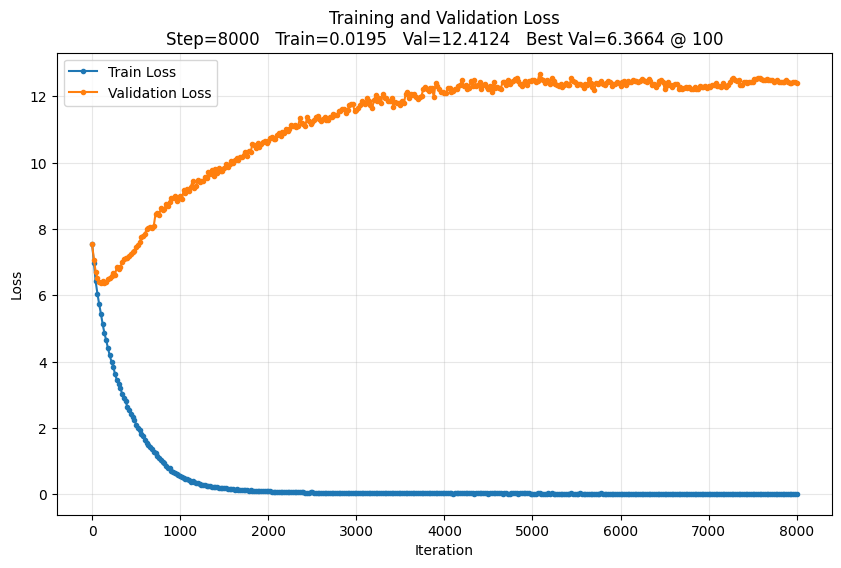

Overriding: dataset = jp
Overriding: device = cuda
Overriding: compile = False
Overriding: init_from = scratch
Overriding: n_layer = 2
Overriding: n_head = 2
Overriding: n_embd = 128
Overriding: batch_size = 8
Overriding: gradient_accumulation_steps = 1
Overriding: block_size = 256
Overriding: max_iters = 8000
Overriding: lr_decay_iters = 8000
Overriding: warmup_iters = 20
Overriding: learning_rate = 0.0004
Overriding: min_lr = 3e-05
Overriding: eval_interval = 20
Overriding: eval_iters = 20
Overriding: dropout = 0.1
Overriding: log_interval = 10
Overriding: dtype = float16
tokens per iteration will be: 2,048
found vocab_size = 1876 (inside data/jp/meta.pkl)
Initializing a new model from scratch
number of parameters: 0.63M
/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 10, with 66

In [ ]:
# @title STEP 5 　Transformerで学習させます。　CPU環境では --device=cpu とし、 GPUが使えるなら　--device=cuda にする。
# ============================================================
# nanoGPT学習 + Train/Validation Loss リアルタイムグラフ
# Google Colab用
# ============================================================

import os
import re
import subprocess
import matplotlib.pyplot as plt
from IPython.display import display

os.chdir("/content/nanoGPT")

# =========================
# 学習コマンド
# -u が重要：出力をリアルタイム化
# =========================
cmd = [
    "python", "-u", "train.py",
    "--dataset=jp",
    "--device=cuda",
    "--compile=False",
    "--init_from=scratch",
    "--n_layer=2",
    "--n_head=2",
    "--n_embd=128",
    "--batch_size=8",
    "--gradient_accumulation_steps=1",
    "--block_size=256",
    "--max_iters=8000",
    "--lr_decay_iters=8000",
    "--warmup_iters=20",
    "--learning_rate=4e-4",
    "--min_lr=3e-5",
    "--eval_interval=20",
    "--eval_iters=20",
    "--dropout=0.1",
    "--log_interval=10",
    "--dtype=float16"
]

# =========================
# loss行を検出
# =========================
pattern = re.compile(
    r"step\s+(\d+):\s+"
    r"train loss\s+([0-9.eE+-]+),\s+"
    r"val loss\s+([0-9.eE+-]+)"
)

steps = []
train_losses = []
val_losses = []

# =========================
# グラフ準備
# =========================
plt.ion()

fig, ax = plt.subplots(figsize=(10, 6))

train_line, = ax.plot(
    [],
    [],
    marker="o",
    markersize=3,
    label="Train Loss"
)

val_line, = ax.plot(
    [],
    [],
    marker="o",
    markersize=3,
    label="Validation Loss"
)

ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.grid(True, alpha=0.3)
ax.legend()

display_handle = display(
    fig,
    display_id=True
)

plt.close(fig)

# =========================
# train.py起動
# =========================
process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

# =========================
# リアルタイム監視
# =========================
for line in iter(process.stdout.readline, ""):

    # 通常ログも表示
    print(line, end="", flush=True)

    m = pattern.search(line)

    if not m:
        continue

    step = int(m.group(1))
    train_loss = float(m.group(2))
    val_loss = float(m.group(3))

    steps.append(step)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # =========================
    # グラフデータ更新
    # =========================
    train_line.set_data(
        steps,
        train_losses
    )

    val_line.set_data(
        steps,
        val_losses
    )

    ax.relim()
    ax.autoscale_view()

    # =========================
    # タイトルに現在値表示
    # =========================
    best_val = min(val_losses)
    best_index = val_losses.index(best_val)
    best_step = steps[best_index]

    ax.set_title(
        f"Training and Validation Loss\n"
        f"Step={step}   "
        f"Train={train_loss:.4f}   "
        f"Val={val_loss:.4f}   "
        f"Best Val={best_val:.4f} @ {best_step}"
    )

    # =========================
    # Colab上のグラフを更新
    # =========================
    fig.canvas.draw()

    display_handle.update(fig)

process.stdout.close()

return_code = process.wait()

# =========================
# 最終結果
# =========================
print()
print("====================================")
print("TRAINING FINISHED")
print("return code :", return_code)

if val_losses:

    best_val = min(val_losses)
    best_index = val_losses.index(best_val)

    print(
        "Best Val Loss :",
        f"{best_val:.4f}"
    )

    print(
        "Best Step     :",
        steps[best_index]
    )

    print(
        "Evaluation points :",
        len(steps)
    )

else:

    print("WARNING: lossデータを取得できませんでした。")

In [ ]:
# @title STEP6 文章生成をします。
# generate_sp.py
import os
import re
import torch
import sentencepiece as spm
from contextlib import nullcontext

os.chdir("/content/nanoGPT")
from model import GPTConfig, GPT

# =========================
# 設定
# =========================
out_dir = "out"
sp_model_path = "/content/nanoGPT/jp.model"

prompt = "メロスは激怒した"
num_samples = 1
max_new_tokens = 500

device = "cuda" if torch.cuda.is_available() else "cpu"

repetition_penalty = 1.1
temperature = 0.2
top_k = 20
top_p = 0.9

temperature = 0.01
top_k = 1
top_p = 1.0
repetition_penalty = 1.0

# =========================
# SentencePiece
# =========================
sp = spm.SentencePieceProcessor()
sp.load(sp_model_path)

def encode(s):
    return sp.encode(s, out_type=int)

def decode(l):
    return sp.decode(l)

# =========================
# 表示整形
# 日本語・英語対応
# =========================
def format_text(text):
    # 日本語
    # 。！？ の後で改行
    # 閉じ括弧 」』）】］” が続く場合も対応
    text = re.sub(
        r'([。！？]+[」』）】］”"]*)[ \t]*',
        r'\1\n',
        text
    )

    # 英語
    # . ! ? の後に空白がある場合に改行
    # " ' などが続く場合にも対応
    text = re.sub(
        r'([.!?]+["\']?)[ \t]+',
        r'\1\n',
        text
    )

    # 行末の余分な空白を削除
    text = re.sub(r'[ \t]+\n', '\n', text)

    # 3個以上の連続改行を2個までにする
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()

# =========================
# モデル読み込み
# =========================
ckpt_path = os.path.join(out_dir, "ckpt.pt")
checkpoint = torch.load(ckpt_path, map_location=device)

model = GPT(GPTConfig(**checkpoint["model_args"]))
state_dict = checkpoint["model"]

# compile対策
for k in list(state_dict.keys()):
    if k.startswith("_orig_mod."):
        state_dict[k[len("_orig_mod."):]] = state_dict.pop(k)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

ctx = nullcontext()

# =========================
# 生成
# =========================
def generate(model, idx, max_new_tokens):
    block_size = model.config.block_size
    last_tokens = []

    for _ in range(max_new_tokens):
        idx_cond = (
            idx
            if idx.size(1) <= block_size
            else idx[:, -block_size:]
        )

        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature

        # -------------------------
        # repetition penalty
        # -------------------------
        for token in set(idx[0].tolist()):
            logits[0][token] /= repetition_penalty

        # -------------------------
        # top_k
        # -------------------------
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            v, _ = torch.topk(logits, k)
            logits[logits < v[:, [-1]]] = -float("Inf")

        # -------------------------
        # top_p
        # -------------------------
        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(
                logits,
                descending=True
            )

            cumulative_probs = torch.cumsum(
                torch.softmax(sorted_logits, dim=-1),
                dim=-1
            )

            sorted_indices_to_remove = cumulative_probs > top_p

            sorted_indices_to_remove[..., 1:] = (
                sorted_indices_to_remove[..., :-1].clone()
            )

            sorted_indices_to_remove[..., 0] = False

            indices_to_remove = sorted_indices[
                sorted_indices_to_remove
            ]

            logits[0][indices_to_remove] = -float("Inf")

        probs = torch.softmax(logits, dim=-1)

        # -------------------------
        # 直近tokenの反復防止
        # -------------------------
        for _ in range(10):
            next_token = torch.multinomial(
                probs,
                num_samples=1
            )

            if next_token.item() not in last_tokens:
                break

        # -------------------------
        # 履歴更新
        # -------------------------
        last_tokens.append(next_token.item())

        if len(last_tokens) > 10:
            last_tokens.pop(0)

        # -------------------------
        # token追加
        # -------------------------
        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    return idx

# =========================
# 実行
# =========================
start_ids = encode(prompt)

x = torch.tensor(
    start_ids,
    dtype=torch.long,
    device=device
)[None, ...]

with torch.no_grad():
    with ctx:
        for _ in range(num_samples):
            y = generate(
                model,
                x,
                max_new_tokens
            )

            text = decode(y[0].tolist())

            # 日本語・英語の文末で改行
            text = format_text(text)

            print("==========")
            print(text)

number of parameters: 0.63M
メロスは激怒した。
「呆れた王だ。
生かして置けぬ。」
メロスは、単純な男であった。
買い物を、背負ったままで、のそのそ王城にはいって行った。
たちまち彼は、巡邏の警吏に捕縛された。
調べられて、メロスの懐中からは短剣が出て来たので、騒ぎが大きくなってしまった。
メロスは、王の前に引き出された。
「この短刀で何をするつもりであったか。
言え!」暴君ディオニスは静かに、けれども威厳を以て問いつめた。
その王の顔は蒼白で、眉間の皺は、刻み込まれたように深かった。
「市を暴君の手から救うのだ。」
とメロスは悪びれずに答えた。
「おまえがか?」王は、憫笑した。
「仕方の無いやつじゃ。
おまえには、わしの孤独がわからぬ。」
「言うな!」とメロスは、いきり立って反駁した。
「人の心を疑うのは、最も恥ずべき悪徳だ。
王は、民の忠誠をさえ疑って居られる。」
「疑うのが、正当の心構えなのだと、わしに教えてくれたのは、おまえたちだ。
人の心は、あてにならない。
人間は、もともと私慾のかたまりさ。
信じては、ならぬ。」
暴君は落着いて呟き、ほっと溜息をついた。
「わしだって、平和を望んでいるのだが。」
「なんの為の平和だ。
自分の地位を守る為か。」
こんどはメロスが嘲笑した。
「罪の無い人を殺して、何が平和だ。」
「だまれ、下賤の者。」
王は、さっと顔を挙げて報いた。
「口では、どんな清らかな事でも言える。
わしには、人の腹綿の奥底が見え透いてならぬ。
おまえだって、いまに、磔になってから、泣いて詫びたって聞かぬぞ。」
「ああ、王は悧巧だ。
自惚れているがよい。
私は、ちゃんと死ぬる覚悟で居るのに。
命乞いなど決してしない。
ただ、――」と言いかけて、メロスは足もとに視線を落し瞬時ためらい、「ただ、私に情をかけたいつもりなら、処刑までに三日間の日限を与えて下さい。
たった一人の妹に、亭主を持たせてやりたいのです。
三日のうちに、私は村で結婚式を挙げさせ、必ず、ここへ帰って来ます。」
「ばかな。」
と暴君は、嗄れた声で低く笑った。
「とんでもない嘘を言うわ


In [ ]:
# @title 参考 Promptはtrain.bin val.binのどちらにあったか？
# ============================================================
# Promptが元コーパスのどこにあり、
# train / val のどちらに入ったかを調べる
# ============================================================

import os
import sentencepiece as spm

BASE = "/content/nanoGPT"
CORPUS = os.path.join(
    BASE,
    "novel_selected",
    "selected_works_clean.txt"
)
MODEL = os.path.join(BASE, "jp.model")

# ============================================================
# ★ 調べたいprompt
# ============================================================
prompt = "メロスが帰って来た。"

# ============================================================
# コーパス読み込み
# ============================================================
if not os.path.exists(CORPUS):
    raise FileNotFoundError(CORPUS)

if not os.path.exists(MODEL):
    raise FileNotFoundError(MODEL)

with open(CORPUS, "r", encoding="utf-8") as f:
    text = f.read()

# ============================================================
# Tokenizer読み込み
# ============================================================
sp = spm.SentencePieceProcessor()
sp.load(MODEL)

# コーパス全体をtokenize
all_ids = sp.encode(text, out_type=int)

# STEP4と同じ9:1分割
split_index = int(len(all_ids) * 0.9)

print("=" * 70)
print("Prompt:")
print(prompt)
print()
print("Corpus characters :", f"{len(text):,}")
print("Corpus tokens     :", f"{len(all_ids):,}")
print("Train tokens      :", f"{split_index:,}")
print("Val tokens        :", f"{len(all_ids) - split_index:,}")
print("Token split index :", f"{split_index:,}")
print("=" * 70)

# ============================================================
# 文字列としてpromptを検索
# ============================================================
char_positions = []

start = 0

while True:
    pos = text.find(prompt, start)

    if pos == -1:
        break

    char_positions.append(pos)
    start = pos + 1

print()
print("=== Character Search ===")
print("文字列としての出現回数:", len(char_positions))

if not char_positions:
    print()
    print("元コーパスにこのpromptは存在しません。")
else:
    # ========================================================
    # 各出現位置についてtrain / valを判定
    # ========================================================
    for n, char_pos in enumerate(char_positions, 1):

        char_end = char_pos + len(prompt)

        # prompt開始位置までの全文をtokenize
        # → これで実際のコーパス文脈を維持したtoken位置を求める
        before_text = text[:char_pos]
        through_text = text[:char_end]

        token_start = len(
            sp.encode(before_text, out_type=int)
        )

        token_end = len(
            sp.encode(through_text, out_type=int)
        )

        # ====================================================
        # train / val判定
        # ====================================================
        if token_end <= split_index:
            location = "TRAIN"

        elif token_start >= split_index:
            location = "VAL"

        else:
            location = "TRAIN / VAL 境界をまたぐ"

        # ====================================================
        # 前後の文字列を表示
        # ====================================================
        context_start = max(0, char_pos - 50)
        context_end = min(
            len(text),
            char_end + 50
        )

        context = text[
            context_start:context_end
        ]

        context = context.replace(
            "\n",
            " "
        )

        # ====================================================
        # 結果
        # ====================================================
        print()
        print("-" * 70)
        print(f"Occurrence #{n}")
        print("-" * 70)

        print(
            "Character position :",
            f"{char_pos:,}",
            "-",
            f"{char_end:,}"
        )

        print(
            "Token position     :",
            f"{token_start:,}",
            "-",
            f"{token_end:,}"
        )

        print(
            "Location           :",
            location
        )

        print()
        print("Context:")
        print(context)

        # ====================================================
        # その場所のtokenを表示
        # ====================================================
        local_start = max(
            0,
            token_start - 5
        )

        local_end = min(
            len(all_ids),
            token_end + 5
        )

        local_ids = all_ids[
            local_start:local_end
        ]

        print()
        print("Nearby token IDs:")
        print(local_ids)

        print()
        print("Nearby pieces:")
        print(
            [
                sp.id_to_piece(i)
                for i in local_ids
            ]
        )

    # ========================================================
    # 最終まとめ
    # ========================================================
    print()
    print("=" * 70)
    print("=== SUMMARY ===")
    print("=" * 70)

    train_count = 0
    val_count = 0
    boundary_count = 0

    for char_pos in char_positions:

        char_end = char_pos + len(prompt)

        token_start = len(
            sp.encode(
                text[:char_pos],
                out_type=int
            )
        )

        token_end = len(
            sp.encode(
                text[:char_end],
                out_type=int
            )
        )

        if token_end <= split_index:
            train_count += 1

        elif token_start >= split_index:
            val_count += 1

        else:
            boundary_count += 1

    print("Prompt              :", repr(prompt))
    print("Total occurrences   :", len(char_positions))
    print("TRAIN occurrences   :", train_count)
    print("VAL occurrences     :", val_count)
    print("Boundary occurrences:", boundary_count)

    print()

    if train_count > 0 and val_count == 0:
        print("判定: このpromptはTRAIN側に存在します。")
        print("→ モデルは学習時にこの文章を見ています。")

    elif val_count > 0 and train_count == 0:
        print("判定: このpromptはVAL側にのみ存在します。")
        print("→ モデルは学習時にこの文章を直接は見ていません。")

    elif train_count > 0 and val_count > 0:
        print("判定: このpromptはTRAINとVALの両方に存在します。")

    elif boundary_count > 0:
        print("判定: このpromptはTRAIN/VAL境界をまたいでいます。")

Prompt:
メロスが帰って来た。

Corpus characters : 9,905
Corpus tokens     : 5,979
Train tokens      : 5,381
Val tokens        : 598
Token split index : 5,381

=== Character Search ===
文字列としての出現回数: 1

----------------------------------------------------------------------
Occurrence #1
----------------------------------------------------------------------
Character position : 8,866 - 8,876
Token position     : 5,417 - 5,421
Location           : VAL

Context:
、消えようとした時、メロスは疾風の如く刑場に突入した。間に合った。 「待て。その人を殺してはならぬ。メロスが帰って来た。約束のとおり、いま、帰って来た。」と大声で刑場の群衆にむかって叫んだつもりであったが、喉がつぶれて嗄

Nearby token IDs:
[295, 941, 262, 339, 261, 303, 1111, 270, 261, 897, 1673, 282, 260, 384]

Nearby pieces:
['その', '人を殺して', 'は', 'ならぬ', '。', 'メロス', 'が帰って来', 'た', '。', '約束の', 'とお', 'り', '、', 'いま']

=== SUMMARY ===
Prompt              : 'メロスが帰って来た。'
Total occurrences   : 1
TRAIN occurrences   : 0
VAL occurrences     : 1
Boundary occurrences: 0

判定: このpromptはVAL側にのみ存在します。
→ モデルは学習時にこの文章を直接は見ていません。


In [ ]:
# @title validation用のデータを見る。
# ============================================================
# Validationに使われている文章を読みやすく表示
# 文末で適度に改行
# ============================================================

import os
import re
import numpy as np
import sentencepiece as spm

BASE = "/content/nanoGPT"
MODEL = os.path.join(BASE, "jp.model")
TRAIN_BIN = os.path.join(BASE, "data", "jp", "train.bin")
VAL_BIN = os.path.join(BASE, "data", "jp", "val.bin")

# =========================
# Tokenizer読み込み
# =========================
sp = spm.SentencePieceProcessor()
sp.load(MODEL)

# =========================
# train / val読み込み
# =========================
train_ids = np.fromfile(
    TRAIN_BIN,
    dtype=np.uint16
)

val_ids = np.fromfile(
    VAL_BIN,
    dtype=np.uint16
)

print("train tokens =", f"{len(train_ids):,}")
print("val tokens   =", f"{len(val_ids):,}")

# =========================
# 読みやすく整形
# =========================
def format_text(text):
    # 既存の余分な空白を整理
    text = re.sub(r"[ \t]+", " ", text)

    # 日本語の文末で改行
    # 閉じ括弧がある場合はその後で改行
    text = re.sub(
        r'([。！？]+[」』）】］”"]*)\s*',
        r'\1\n',
        text
    )

    # 空行が増えすぎないようにする
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()

# =========================
# TRAIN末尾100 token
# =========================
train_tail = sp.decode(
    [int(i) for i in train_ids[-100:]]
)

train_tail = format_text(train_tail)

# =========================
# VALIDATION全文
# =========================
val_text = sp.decode(
    [int(i) for i in val_ids]
)

val_text = format_text(val_text)

# =========================
# 表示
# =========================
print()
print("=" * 70)
print("TRAIN 最後の100 tokens")
print("=" * 70)
print(train_tail)

print()
print("=" * 70)
print("↑ TRAIN / VALIDATION 境界 ↓")
print("=" * 70)

print()
print("VALIDATION 全文")
print("=" * 70)
print(val_text)

print()
print("=" * 70)
print("END OF VALIDATION DATA")
print("=" * 70)

RuntimeError: NOT_FOUND: "/content/nanoGPT/jp.model": No such file or directory Error #2

In [ ]:
# @title デ環境を自分のGoogle Driveに保存する。
from google.colab import drive
import shutil
import os

drive.mount("/content/drive")

SOURCE = "/content/nanoGPT"
DEST = "/content/drive/MyDrive/nanoGPT-class1"

# 既にバックアップがあれば更新
if os.path.exists(DEST):
    shutil.rmtree(DEST)

print("Google Driveへ保存中...")
shutil.copytree(SOURCE, DEST)

print("保存完了")
print(DEST)

Mounted at /content/drive
Google Driveへ保存中...
保存完了
/content/drive/MyDrive/nanoGPT-class1


In [ ]:
# @title Google Driveから環境を復帰する。
from google.colab import drive
import shutil

drive.mount("/content/drive")

shutil.copytree(
    "/content/drive/MyDrive/nanoGPT-class1",
    "/content/nanoGPT",
    dirs_exist_ok=True
)

print("nanoGPT環境を復元しました。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
nanoGPT環境を復元しました。
